## Code for plotting Site U1562 XRF data 

In [1]:
import pandas, numpy, scipy, matplotlib, seaborn
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker
import scipy.signal as signal
from scipy.signal import savgol_filter
from scipy.signal import find_peaks
import numpy as np
from scipy.stats import spearmanr
import seaborn as sns
from matplotlib.transforms import blended_transform_factory
import matplotlib.patches as mpatches

In [26]:
###  Import Site U1562 XRF data ###

# Splice
splice_10kV = pd.read_csv('data/U1562/splice/395-U1562_10kV_0_16mA_No-Filter_6s_DC10mm_CC12mm_Clean.csv')
splice_30kV = pd.read_csv('data/U1562/splice/395-U1562_30kV_1_25mA_Pd-Thick_6s_DC10mm_CC12mm_Clean.csv')
splice_50kV = pd.read_csv('data/U1562/splice/395-U1562_50kV_0_75mA_Cu_10s_DC10mm_CC12mm_Clean.csv')

## U1562 splice physical properties ##
splice_ms = pd.read_csv('data/U1562/MS_Point_U1562_clean.csv')
splice_ngr = pd.read_csv('data/U1562/NGR_U1562_clean.csv')

splice_ms  = splice_ms.sort_values('Depth CCSF-395-U1562-AC-20230704-shipboard1 (m)').reset_index(drop=True)
splice_ngr = splice_ngr.sort_values('Depth CCSF-395-U1562-AC-20230704-shipboard1 (m)').reset_index(drop=True)

## U1562 age model and lith units ##
agemodel = pd.read_csv('data/U1562/U1562-agemodel-csf-ccsf.csv')
lithunits=pd.read_csv('data/U1562/U1562-lithunits-csf-ccsf.csv')


In [3]:
GSA_EPOCH_COLORS = {
    'Pleistocene': '#FEEFBC',
    'Pliocene':    '#FFF8AE',
    'Miocene':     '#FFF101',
    'Oligocene':   '#FEDAAB',
    'Eocene':      '#FBBB85',
}

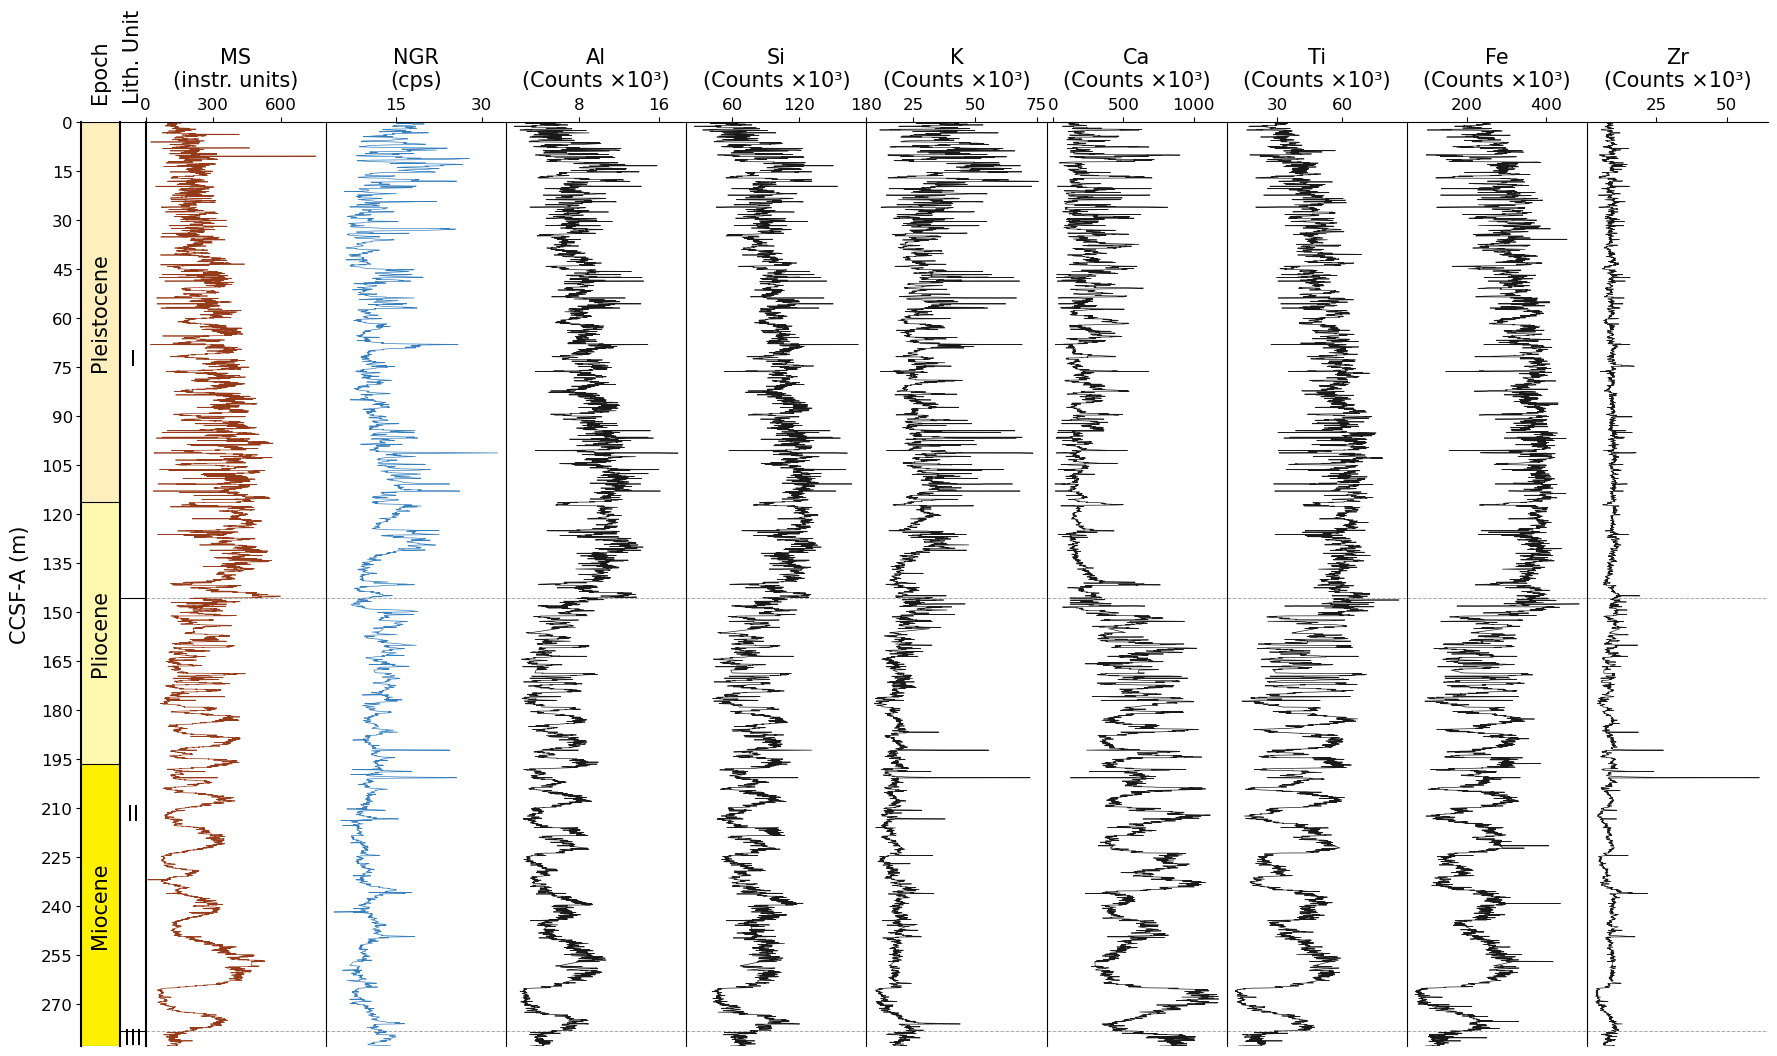

In [30]:
depth = 'CCSF-395-U1562-AC-20230704-shipboard1 (m)'
depth_pp = 'Depth CCSF-395-U1562-AC-20230704-shipboard1 (m)'

colors = {
    'Al': 'black', 'Si': 'black', 'K':  'black', 'Ca': 'black',
    'Ti': 'black', 'Fe': 'black', 'Zr': 'black',
}
elements = {
    'Al': (splice_10kV, 'Al-Ka Area'),
    'Si': (splice_10kV, 'Si-Ka Area'),
    'K':  (splice_10kV, 'K -Ka Area'),
    'Ca': (splice_10kV, 'Ca-Ka Area'),
    'Ti': (splice_10kV, 'Ti-Ka Area'),
    'Fe': (splice_10kV, 'Fe-Ka Area'),
    'Zr': (splice_30kV, 'Zr-Ka Area'),
}

extra_panels = [
    {
        'df':    splice_ms,
        'xcol':  'Magnetic susceptibility (instr. units)',
        'ycol':  depth_pp,
        'label': 'MS\n(instr. units)',
        'color': '#8B2500',
        'xlim':  (0, 800),
    },
    {
        'df':    splice_ngr,
        'xcol':  'NGR total counts (cps)',
        'ycol':  depth_pp,
        'label': 'NGR\n(cps)',
        'color': '#2171B5',
        'xlim':  (None, None),
    },
]

lith_boundaries  = [0.0] + list(lithunits['Depth CCSF-A (m)'])
lith_labels      = ['']  + list(lithunits['Lithostrat Unit'])

epoch_boundaries = [0.0] + list(agemodel['Depth CCSF-A (m)'])
epoch_labels     = ['']  + list(agemodel['Event (base)'])

boundaries = list(lithunits['Depth CCSF-A (m)'])

y_min = 0
y_max = max(splice_10kV[depth].max(), splice_30kV[depth].max())

n_extra = len(extra_panels)
n_xrf   = len(elements)
n_cols  = 1 + 1 + 1 + n_extra + n_xrf   # depth | epoch | lith | MS | NGR | XRF...

fig = plt.figure(figsize=(4 + 2*(n_extra + n_xrf), 12))
gs  = gridspec.GridSpec(1, n_cols,
                        width_ratios=[0.10, 0.22, 0.14] + [1]*(n_extra + n_xrf),
                        wspace=0.0)

# ── depth axis ────────────────────────────────────────────────────────────────
ax_depth = fig.add_subplot(gs[0])
ax_depth.set_ylim(y_max, y_min)
ax_depth.set_xlim(0, 1)
ax_depth.set_xticks([])
ax_depth.yaxis.set_major_locator(plt.MaxNLocator(25))
ax_depth.tick_params(axis='y', labelsize=12, left=True, labelleft=True,
                     right=False, pad=2)
ax_depth.set_ylabel('CCSF-A (m)', fontsize=15, labelpad=8)
for spine in ax_depth.spines.values():
    spine.set_visible(False)
ax_depth.spines['left'].set_visible(True)

# ── epoch axis ────────────────────────────────────────────────────────────────
ax_age = fig.add_subplot(gs[1], sharey=ax_depth)
draw_boundaries(ax_age, epoch_boundaries, epoch_labels,
                fontsize=15, rotation=90,
                left_line=True, right_line=False,
                epoch_colors=GSA_EPOCH_COLORS, y_max=y_max)
ax_age.text(0.5, 1.02, 'Epoch', fontsize=15,
            ha='center', va='bottom', rotation=90,
            transform=ax_age.transAxes)

# ── lith axis ─────────────────────────────────────────────────────────────────
ax_lith = fig.add_subplot(gs[2], sharey=ax_depth)
draw_boundaries(ax_lith, lith_boundaries, lith_labels,
                fontsize=15, rotation=0,
                left_line=True, right_line=True, y_max=y_max)
ax_lith.text(0.5, 1.02, 'Lith. Unit', fontsize=15,
             ha='center', va='bottom', rotation=90,
             transform=ax_lith.transAxes)

# ── MS and NGR panels ─────────────────────────────────────────────────────────
extra_axes = [fig.add_subplot(gs[i+3], sharey=ax_depth) for i in range(n_extra)]

for i, (ax, panel) in enumerate(zip(extra_axes, extra_panels)):
    for b in boundaries:
        ax.axhline(b, color='#aaaaaa', linewidth=0.7, linestyle='--', zorder=1)

    ax.plot(panel['df'][panel['xcol']], panel['df'][panel['ycol']],
            color=panel['color'], linewidth=0.5, alpha=0.9)

    lo, hi = panel['xlim']
    if lo is not None or hi is not None:
        cur_lo, cur_hi = ax.get_xlim()
        ax.set_xlim(lo if lo is not None else cur_lo,
                    hi if hi is not None else cur_hi)

    ax.xaxis.set_major_locator(plt.MaxNLocator(3))
    ax.xaxis.set_label_position('top')
    ax.xaxis.tick_top()
    ax.set_xlabel(panel['label'], fontsize=15, labelpad=8)
    ax.tick_params(axis='x', labelsize=12, top=True, labeltop=True,
                   bottom=False, labelbottom=False)
    ax.tick_params(axis='y', labelleft=False, left=False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if i == 0:
        ax.spines['left'].set_visible(True)

# ── XRF element panels ────────────────────────────────────────────────────────
all_axes = [fig.add_subplot(gs[i+3+n_extra], sharey=ax_depth) for i in range(n_xrf)]

for i, (ax, (element, (df, col))) in enumerate(zip(all_axes, elements.items())):
    for b in boundaries:
        ax.axhline(b, color='#aaaaaa', linewidth=0.7, linestyle='--', zorder=1)

    ax.plot(df[col], df[depth], color=colors[element], linewidth=0.5, alpha=0.9)

    ax.xaxis.set_major_locator(plt.MaxNLocator(3))
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda val, pos: f'{val/1000:.0f}'))
    ax.xaxis.set_label_position('top')
    ax.xaxis.tick_top()
    ax.set_xlabel(f'{element}\n(Counts ×10³)', fontsize=15, labelpad=8)
    ax.tick_params(axis='x', labelsize=12, top=True, labeltop=True,
                   bottom=False, labelbottom=False)
    ax.tick_params(axis='y', labelleft=False, left=False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if i == 0:
        ax.spines['left'].set_visible(True)

# ── flush to depth spine ──────────────────────────────────────────────────────
fig.canvas.draw()
spine_x   = ax_depth.spines['left'].get_window_extent().x1
lith_left = fig.transFigure.inverted().transform((spine_x, 0))[0]
shift     = ax_age.get_position().x0 - lith_left

for ax in [ax_age, ax_lith] + extra_axes + all_axes:
    pos = ax.get_position()
    ax.set_position([pos.x0 - shift, pos.y0, pos.width, pos.height])

plt.show()

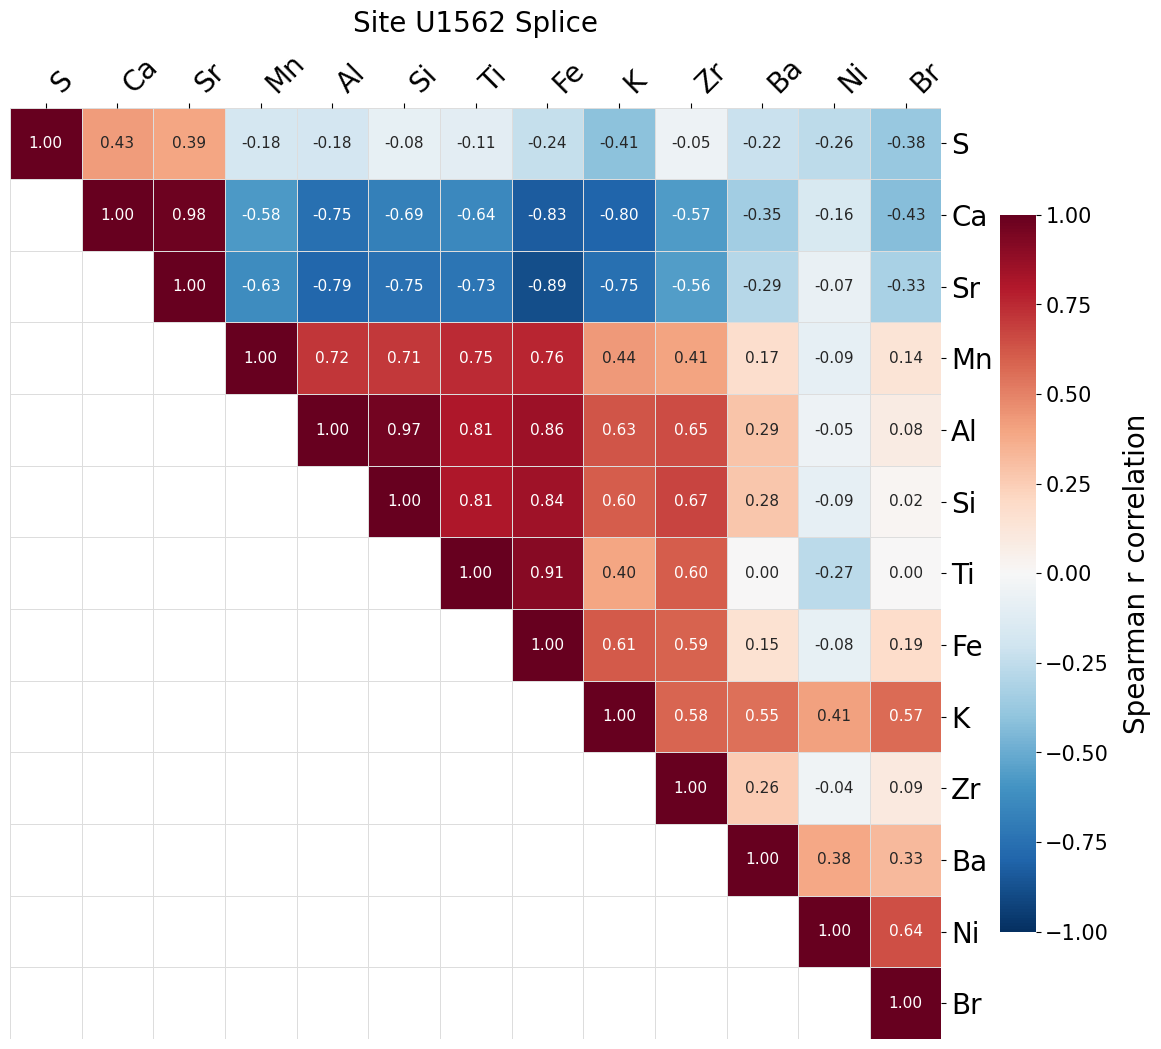

In [32]:
# S, Ca, Al, Si, Ti, Fe, K, Mn from 10kV
# Zr, Sr, Ni, Br from 30kV
# Ba from 50kV
elements_corr = {
    'S':  splice_10kV['S -Ka Area'],
    'Ca': splice_10kV['Ca-Ka Area'],
    'Sr': splice_30kV['Sr-Ka Area'],
    'Mn': splice_10kV['Mn-Ka Area'],
    'Al': splice_10kV['Al-Ka Area'],
    'Si': splice_10kV['Si-Ka Area'],
    'Ti': splice_10kV['Ti-Ka Area'],
    'Fe': splice_10kV['Fe-Ka Area'],
    'K':  splice_10kV['K -Ka Area'],
    'Zr': splice_30kV['Zr-Ka Area'],
    'Ba': splice_50kV['Ba-Ka Area'],
    'Ni': splice_30kV['Ni-Ka Area'],
    'Br': splice_30kV['Br-Ka Area'],
}

df_corr = pd.DataFrame({k: v.values for k, v in elements_corr.items()})
corr_matrix = df_corr.corr(method='spearman')

fig, ax = plt.subplots(figsize=(12, 11))
mask = np.tril(np.ones_like(corr_matrix, dtype=bool), k=-1)
sns.heatmap(corr_matrix,
            mask=mask,
            annot=True,
            fmt='.2f',
            cmap='RdBu_r',
            vmin=-1, vmax=1,
            square=True,
            linewidths=0.5,
            linecolor='#dddddd',
            annot_kws={'size': 11},
            cbar_kws={'shrink': 0.7},
            ax=ax)
ax.set_title('Site U1562 Splice', fontsize=20, pad=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='left', fontsize=20)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=20)
ax.xaxis.tick_top()
ax.yaxis.tick_right()
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=15)
cbar.set_label('Spearman r correlation', fontsize=20, labelpad=10)
plt.tight_layout()
plt.show()

In [40]:
## prep for the correlation plots

def get_element(name):
    sources = {
        'Al': splice_10kV['Al-Ka Area'],
        'Si': splice_10kV['Si-Ka Area'],
        'K':  splice_10kV['K -Ka Area'],
        'Ca': splice_10kV['Ca-Ka Area'],
        'Ti': splice_10kV['Ti-Ka Area'],
        'Fe': splice_10kV['Fe-Ka Area'],
        'Zr': splice_30kV['Zr-Ka Area'],
        'Ba': splice_50kV['Ba-Ka Area'],
        'Br': splice_30kV['Br-Ka Area'],
        'Sr': splice_30kV['Sr-Ka Area'],
        'Rb': splice_30kV['Rb-Ka Area'], 
    }
    return sources[name]

pairs = [
    ('Ca', 'Fe'),
    ('Fe', 'Ti'),
    ('Zr', 'Rb'),
    ('Si', 'Ca'),
    ('K',  'Fe'),
    ('Ti', 'Ca'),
    ('Si', 'Ti'),
    ('Ba', 'Br'),
    ('Sr', 'Ca'),
]

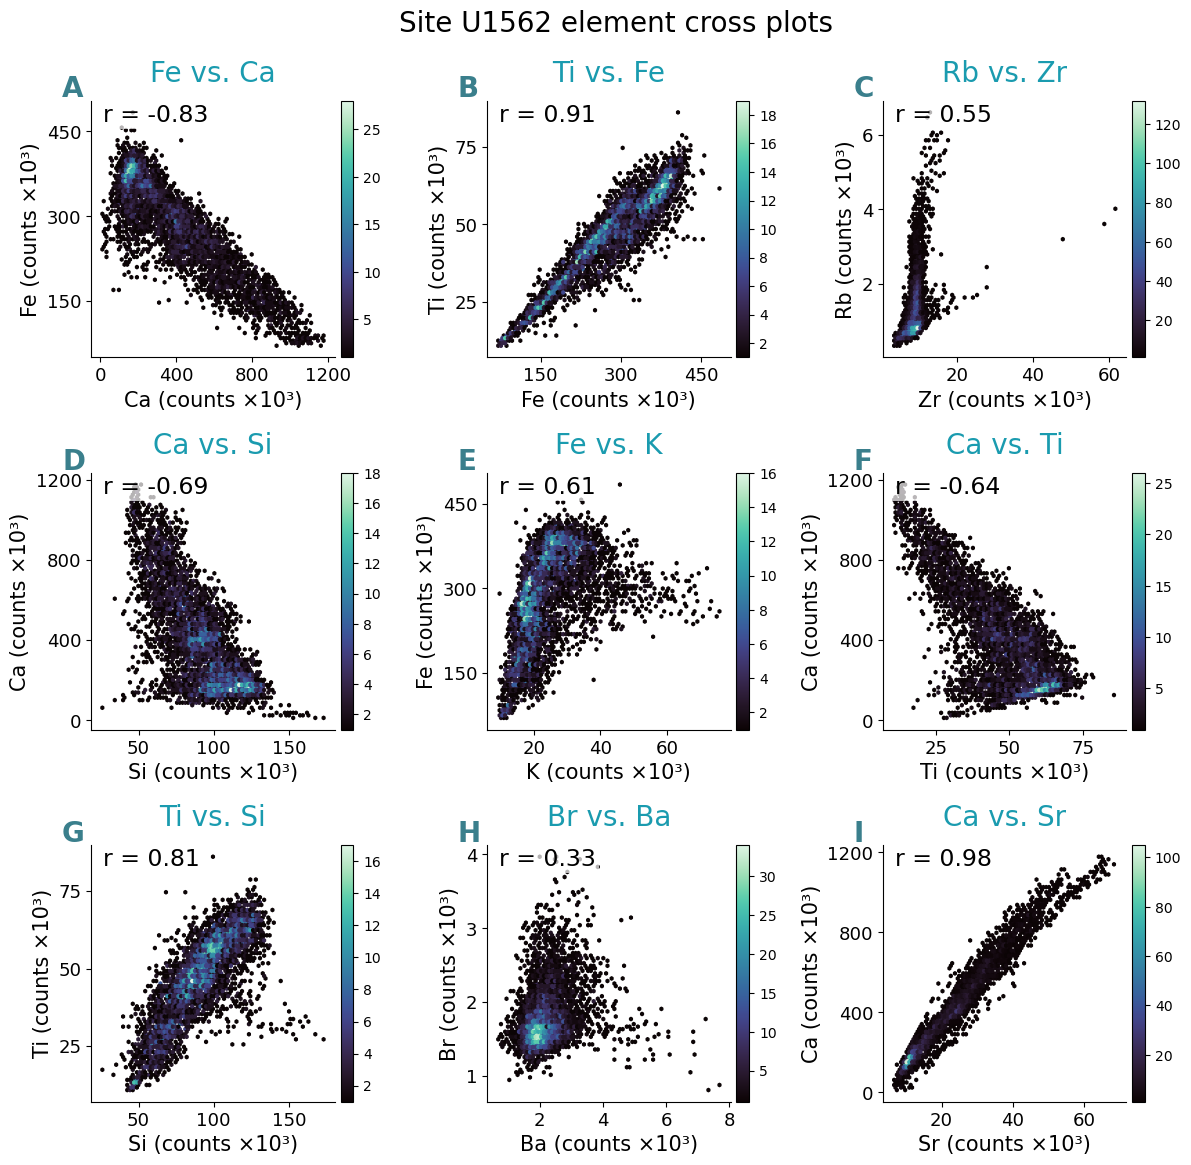

In [41]:
fig, axes = plt.subplots(3, 3, figsize=(14, 13))
axes = axes.flatten()
for ax, (xvar, yvar) in zip(axes, pairs):
    x = get_element(xvar)
    y = get_element(yvar)
    
    df_pair = pd.DataFrame({xvar: x.values[:min(len(x), len(y))], 
                             yvar: y.values[:min(len(x), len(y))]}).dropna()
    
    x_clean = df_pair[xvar]
    y_clean = df_pair[yvar]
    
    hb = ax.hexbin(x_clean, y_clean, gridsize=80, cmap='mako', mincnt=1)
    fig.colorbar(hb, ax=ax, pad=0.02)
    
    r, p = spearmanr(x_clean, y_clean)
    ax.text(0.05, 0.92, f'r = {r:.2f}', transform=ax.transAxes,
            fontsize=17, color='black',
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, pad=2))
    
    title_color = '#1A9BAF'
    ax.set_title(f'{yvar} vs. {xvar}', fontsize=20, color=title_color, pad=14)
    
    panel_label = chr(65 + list(axes).index(ax))
    ax.text(-0.12, 1.1, panel_label, transform=ax.transAxes,
            fontsize=20, color='#3a7f8c', fontweight='bold', va='top')
    
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda val, pos: f'{val/1000:.0f}'))
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda val, pos: f'{val/1000:.0f}'))
    ax.set_xlabel(f'{xvar} (counts ×10³)', fontsize=12)
    ax.set_ylabel(f'{yvar} (counts ×10³)', fontsize=12)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(labelsize=11)
    ax.xaxis.set_major_locator(ticker.MaxNLocator(4))
    ax.yaxis.set_major_locator(ticker.MaxNLocator(4))

for ax in axes[:len(pairs)]:
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda val, pos: f'{val/1000:.0f}'))
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda val, pos: f'{val/1000:.0f}'))
    ax.set_xlabel(ax.get_xlabel(), fontsize=15)
    ax.set_ylabel(ax.get_ylabel(), fontsize=15)
    ax.tick_params(labelsize=13)

fig.suptitle('Site U1562 element cross plots', fontsize=20, y=0.95)
plt.subplots_adjust(hspace=0.45, wspace=0.35)
plt.show()
